In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

In [3]:
df['hour'] = df['datetime'].dt.hour
weekend_data = df[df['workingday'] == 0]          # workingday=0 означает выходные/праздничные дни
hourly_avg = weekend_data.groupby('hour')['count'].mean()
best_hour = hourly_avg.idxmax()
best_avg = hourly_avg.max()
print(f"Среднее число поездок в выходные максимально в час: {best_hour}:00, среднее = {best_avg:.1f}")

Среднее число поездок в выходные максимально в час: 13:00, среднее = 387.8


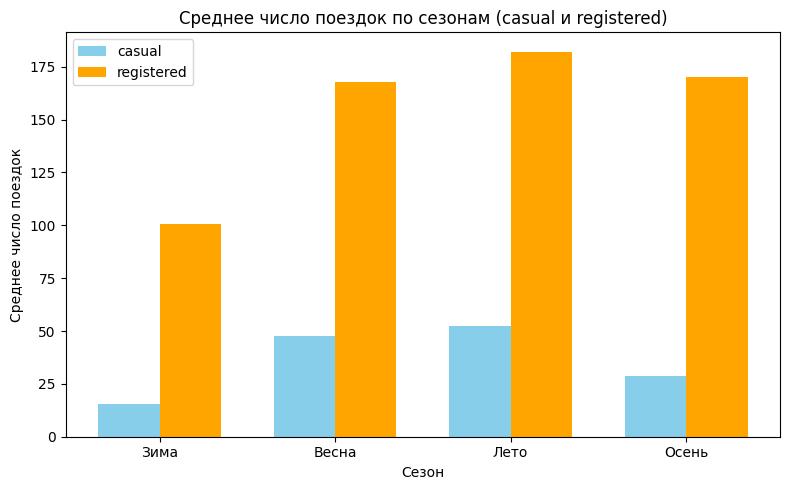

In [7]:
# Task 2 (исправленный порядок сезонов)
season_names = {1: 'Зима', 2: 'Весна', 3: 'Лето', 4: 'Осень'}
df['season_name'] = df['season'].map(season_names)

correct_order = ['Зима', 'Весна', 'Лето', 'Осень']
df['season_name'] = pd.Categorical(df['season_name'], categories=correct_order, ordered=True)

seasonal_avg = df.groupby('season_name', observed=False)[['casual', 'registered']].mean().reset_index()

x = np.arange(len(seasonal_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, seasonal_avg['casual'], width, label='casual', color='skyblue')
ax.bar(x + width/2, seasonal_avg['registered'], width, label='registered', color='orange')

ax.set_xlabel('Сезон')
ax.set_ylabel('Среднее число поездок')
ax.set_title('Среднее число поездок по сезонам (casual и registered)')
ax.set_xticks(x)
ax.set_xticklabels(seasonal_avg['season_name'])
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
high_traffic = df[df['count'] > 500]
num_high = len(high_traffic)
season_counts = high_traffic['season_name'].value_counts()

print(f"Результат задачи 4: Количество наблюдений с count > 500: {num_high}")
print("Распределение по сезонам:")
print(season_counts)
most_freq_season = season_counts.idxmax()
print(f"Чаще всего такие наблюдения встречаются в сезоне: {most_freq_season} ({season_counts.max()} раз)")

Результат задачи 4: Количество наблюдений с count > 500: 797
Распределение по сезонам:
season_name
Весна    281
Лето     271
Осень    186
Зима      59
Name: count, dtype: int64
Чаще всего такие наблюдения встречаются в сезоне: Весна (281 раз)


In [6]:
# Загрузка данных
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# Извлечение месяца
df["month"] = df["datetime"].dt.month

# Группировка по месяцам: средняя температура и среднее число поездок
monthly_stats = df.groupby("month").agg({
    "temp": "mean",
    "count": "mean"
}).round(2)

# Переименование индексов в русские названия месяцев
month_names = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр", 5: "Май", 6: "Июн",
    7: "Июл", 8: "Авг", 9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}
monthly_stats.index = [month_names[m] for m in monthly_stats.index]

# Вывод на экран
print(monthly_stats)

# Сохранение в CSV (с разделителем ; и кодировкой UTF-8)
monthly_stats.to_csv("monthly_temp_rides.csv", sep=";", encoding="utf-8-sig")
print("\nФайл сохранён: monthly_temp_rides.csv")

      temp   count
Янв   9.84   90.37
Фев  11.80  110.00
Мар  15.90  148.17
Апр  18.72  184.16
Май  22.67  219.46
Июн  27.06  242.03
Июл  30.84  235.33
Авг  29.74  234.12
Сен  25.78  233.81
Окт  20.93  227.70
Ноя  15.19  193.68
Дек  13.83  175.61

Файл сохранён: monthly_temp_rides.csv
